# 05 — Sensibilità alla stocasticità latente

In questo notebook viene studiato in modo controllato l’effetto della componente stocastica dello spazio latente sulla ricostruzione del VAE.

Introduciamo il parametro τ nella parametrizzazione:

z_τ = μ + τ σ ε

dove ε è un rumore gaussiano standard. Per τ = 0 si ottiene la ricostruzione deterministica basata su z = μ, mentre τ = 1 corrisponde al normale sampling del VAE.

Nel latent space vale esattamente che lo spostamento quadratico medio rispetto a μ cresce proporzionalmente a τ².

Utilizzando un’approssimazione locale del decoder, ci aspettiamo inoltre che anche la variazione dell’output rispetto alla ricostruzione ottenuta con μ segua, per piccoli valori di τ, una legge approssimativamente quadratica.

Questa relazione viene verificata su quattro modelli rappresentativi della curva Rate–Distortion, corrispondenti a β = 1e-4, 3e-4, 1e-3 e 1e-2.


## 1. Librerie e configurazione

In [1]:
from pathlib import Path
import wave as waveio

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torchaudio

from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SEED = 42
MC_SAMPLES = 10

TAUS = [
    0.0,
    0.25,
    0.5,
    0.75,
    1.0,
    1.25,
    1.5,
    2.0
]

SELECTED = [
    1e-4,
    3e-4,
    1e-3,
    1e-2
]

SAMPLE_RATE = 8000
N_SAMPLES = 8000
N_FFT = 256
HOP_LENGTH = 64
SPEC_H = 128
SPEC_W = 128
LATENT_DIM = 128
BATCH_SIZE = 64

NOISE_STD = 0.05
PADDING_WEIGHT = 0.10

CHECKPOINT_DIR = Path("checkpoints")
RESULTS_DIR = Path("results")

torch.manual_seed(SEED)
np.random.seed(SEED)

print("device:", device)
print("MC samples:", MC_SAMPLES)
print("taus:", TAUS)
print("betas:", SELECTED)


device: cpu
MC samples: 10
taus: [0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0]
betas: [0.0001, 0.0003, 0.001, 0.01]


## 2. Preparazione del dataset e rappresentazione STFT

In [2]:
recordings_dir = Path("audio_data/free-spoken-digit-dataset-1.0.10/recordings")
wav_files = sorted(recordings_dir.glob("*.wav"))

if len(wav_files) == 0:
    raise FileNotFoundError("Dataset FSDD non trovato.")

def parse_name(path):
    digit, speaker, index = path.stem.split("_")
    return int(digit), speaker, int(index)

def load_fixed_audio(path):
    with waveio.open(str(path), "rb") as f:
        sr = f.getframerate()
        channels = f.getnchannels()
        frames = f.readframes(f.getnframes())

    audio = np.frombuffer(frames, dtype=np.int16).astype(np.float32) / 32768.0

    if channels > 1:
        audio = audio.reshape(-1, channels).mean(axis=1)

    waveform = torch.tensor(audio).unsqueeze(0)

    if sr != SAMPLE_RATE:
        waveform = torchaudio.functional.resample(
            waveform, sr, SAMPLE_RATE
        )

    valid_length = min(waveform.shape[1], N_SAMPLES)

    if waveform.shape[1] < N_SAMPLES:
        waveform = F.pad(
            waveform,
            (0, N_SAMPLES - waveform.shape[1])
        )
    else:
        waveform = waveform[:, :N_SAMPLES]

    mask = torch.zeros_like(waveform)
    mask[:, :valid_length] = 1.0

    return waveform, mask, valid_length

train_files = []
test_files = []

for path in wav_files:
    _, _, idx = parse_name(path)

    if idx <= 4:
        test_files.append(path)
    else:
        train_files.append(path)

window = torch.hann_window(N_FFT)

def stft_complex(x):
    return torch.stft(
        x.squeeze(0),
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=N_FFT,
        window=window,
        return_complex=True
    )

def crop_logmag(logmag):
    logmag = logmag[:SPEC_H, :]

    if logmag.shape[1] < SPEC_W:
        logmag = F.pad(
            logmag,
            (0, SPEC_W - logmag.shape[1])
        )
    else:
        logmag = logmag[:, :SPEC_W]

    return logmag

def frame_weights(valid_length):
    valid_frames = int(np.ceil(valid_length / HOP_LENGTH)) + 1
    valid_frames = min(valid_frames, SPEC_W)

    w = torch.full(
        (1, SPEC_H, SPEC_W),
        PADDING_WEIGHT,
        dtype=torch.float32
    )

    w[:, :, :valid_frames] = 1.0
    return w

print("Train:", len(train_files))
print("Test :", len(test_files))


Train: 2700
Test : 300


## 3. Normalizzazione delle rappresentazioni spettrali

In [3]:
sum_x = 0.0
sum_x2 = 0.0
count_values = 0

for path in train_files:
    clean, _, _ = load_fixed_audio(path)

    X = stft_complex(clean)
    logmag = crop_logmag(torch.log1p(X.abs()))

    sum_x += logmag.sum().item()
    sum_x2 += (logmag ** 2).sum().item()
    count_values += logmag.numel()

SPEC_MEAN = sum_x / count_values

variance = (
    sum_x2 / count_values
    - SPEC_MEAN ** 2
)

SPEC_STD = max(variance, 1e-8) ** 0.5

print("SPEC_MEAN:", SPEC_MEAN)
print("SPEC_STD :", SPEC_STD)


SPEC_MEAN: 0.04547776059049216
SPEC_STD : 0.16703430628401916


## 4. Costruzione del test set

In [4]:
class TauDataset(Dataset):
    def __init__(self, files):
        self.files = files

    def __len__(self):
        return len(self.files)

    def __getitem__(self, i):
        clean, mask, valid_length = load_fixed_audio(self.files[i])

        g = torch.Generator().manual_seed(10000 + i)
        noise = torch.randn(clean.shape, generator=g)

        noisy = torch.clamp(
            clean + NOISE_STD * noise * mask,
            -1.0,
            1.0
        )

        clean_stft = stft_complex(clean)
        noisy_stft = stft_complex(noisy)

        clean_logmag = crop_logmag(
            torch.log1p(clean_stft.abs())
        )

        noisy_logmag = crop_logmag(
            torch.log1p(noisy_stft.abs())
        )

        clean_img = (
            (clean_logmag - SPEC_MEAN)
            / SPEC_STD
        ).unsqueeze(0)

        noisy_img = (
            (noisy_logmag - SPEC_MEAN)
            / SPEC_STD
        ).unsqueeze(0)

        weights = frame_weights(valid_length)

        return noisy_img, clean_img, weights

test_loader = DataLoader(
    TauDataset(test_files),
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Test dataset pronto")


Test dataset pronto


## 5. Architettura del VAE e caricamento dei checkpoint

In [5]:
class STFTVAE(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), nn.ReLU()
        )

        self.fc_mu = nn.Linear(
            128 * 16 * 16,
            LATENT_DIM
        )

        self.fc_logvar = nn.Linear(
            128 * 16 * 16,
            LATENT_DIM
        )

        self.fc_decode = nn.Linear(
            LATENT_DIM,
            128 * 16 * 16
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 4, 2, 1)
        )

    def encode(self, x):
        h = self.encoder(x).flatten(1)
        return self.fc_mu(h), self.fc_logvar(h)

    def decode(self, z):
        h = self.fc_decode(z).view(-1, 128, 16, 16)
        return self.decoder(h)


CHECKPOINTS = {
    1e-4: CHECKPOINT_DIR / "vae_beta_1em04.pt",
    3e-4: CHECKPOINT_DIR / "vae_beta_3em04.pt",
    1e-3: CHECKPOINT_DIR / "vae_beta_1em03.pt",
    1e-2: CHECKPOINT_DIR / "vae_beta_1em02.pt"
}

missing = [
    path
    for path in CHECKPOINTS.values()
    if not Path(path).exists()
]

if missing:
    print("Checkpoint mancanti:")
    for path in missing:
        print(" -", path)
    raise FileNotFoundError("Mancano alcuni checkpoint.")

print("Checkpoint trovati")


Checkpoint trovati


## 6. Definizione delle metriche di distorsione

In [6]:
def weighted_mse(recon, target, weights):
    error = (recon - target) ** 2

    numerator = (
        error * weights
    ).sum(dim=(1, 2, 3))

    denominator = (
        weights.sum(dim=(1, 2, 3))
        .clamp_min(1.0)
    )

    return numerator / denominator

def output_displacement(recon_tau, recon_mu, weights):
    error = (recon_tau - recon_mu) ** 2

    numerator = (
        error * weights
    ).sum(dim=(1, 2, 3))

    denominator = (
        weights.sum(dim=(1, 2, 3))
        .clamp_min(1.0)
    )

    return numerator / denominator


## 7. Analisi della perturbazione latente al variare di τ

Per ogni campione Monte Carlo viene utilizzato lo stesso vettore di rumore ε per tutti i valori di τ.

Questa scelta rende il confronto tra diversi livelli di perturbazione più stabile, perché limita la variabilità dovuta a differenti realizzazioni casuali.

Per ciascun valore di τ vengono misurate quattro quantità:

- LatentDisp: distanza quadratica tra z_τ e μ;
- LatentTheory: valore teorico τ² × Σσ_i²;
- OutputDisp: distanza quadratica tra l’output del decoder ottenuto con z_τ e quello ottenuto con μ;
- ReconD: distorsione della ricostruzione rispetto al target pulito.


In [7]:
all_rows = []

for beta in SELECTED:
    print(f"Analizzo beta = {beta:.0e}")

    model = STFTVAE().to(device)

    model.load_state_dict(
        torch.load(
            CHECKPOINTS[beta],
            map_location=device
        )
    )

    model.eval()

    totals = {
        tau: {
            "latent": 0.0,
            "theory": 0.0,
            "output": 0.0,
            "recon": 0.0,
            "count": 0
        }
        for tau in TAUS
    }

    torch.manual_seed(SEED)

    with torch.no_grad():
        for noisy_img, clean_img, weights in test_loader:
            noisy_img = noisy_img.to(device)
            clean_img = clean_img.to(device)
            weights = weights.to(device)

            mu, logvar = model.encode(noisy_img)

            sigma = torch.exp(
                0.5 * logvar
            )

            recon_mu = model.decode(mu)

            batch = noisy_img.size(0)

            for _ in range(MC_SAMPLES):
                eps = torch.randn_like(
                    sigma
                )

                for tau in TAUS:
                    z_tau = (
                        mu
                        + tau * sigma * eps
                    )

                    recon_tau = model.decode(
                        z_tau
                    )

                    latent_disp = (
                        (z_tau - mu) ** 2
                    ).sum(dim=1)

                    latent_theory = (
                        (tau ** 2)
                        * (sigma ** 2).sum(dim=1)
                    )

                    out_disp = output_displacement(
                        recon_tau,
                        recon_mu,
                        weights
                    )

                    recon_d = weighted_mse(
                        recon_tau,
                        clean_img,
                        weights
                    )

                    totals[tau]["latent"] += latent_disp.sum().item()
                    totals[tau]["theory"] += latent_theory.sum().item()
                    totals[tau]["output"] += out_disp.sum().item()
                    totals[tau]["recon"] += recon_d.sum().item()
                    totals[tau]["count"] += batch

    for tau in TAUS:
        n = totals[tau]["count"]

        all_rows.append(
            {
                "beta": beta,
                "tau": tau,
                "tau2": tau ** 2,
                "LatentDisp": totals[tau]["latent"] / n,
                "LatentTheory": totals[tau]["theory"] / n,
                "OutputDisp": totals[tau]["output"] / n,
                "ReconD": totals[tau]["recon"] / n
            }
        )

tau_df = pd.DataFrame(all_rows)

tau_df


Analizzo beta = 1e-04
Analizzo beta = 3e-04
Analizzo beta = 1e-03
Analizzo beta = 1e-02


,beta,tau,tau2,LatentDisp,LatentTheory,OutputDisp,ReconD
0,0.0001,0.00,0.0000,0.000000,0.000000,0.000000,0.249429
1,0.0001,0.25,0.0625,0.510050,0.507211,0.000280,0.249671
2,0.0001,0.50,0.2500,2.040202,2.028842,0.001119,0.250434
3,0.0001,0.75,0.5625,4.590454,4.564894,0.002514,0.251725
4,0.0001,1.00,1.0000,8.160808,8.115368,0.004465,0.253544
5,0.0001,1.25,1.5625,12.751262,12.680262,0.006973,0.255896
6,0.0001,1.50,2.2500,18.361817,18.259578,0.010040,0.258784
7,0.0001,2.00,4.0000,32.643231,32.461472,0.017871,0.266212
8,0.0003,0.00,0.0000,0.000000,0.000000,0.000000,0.252140
9,0.0003,0.25,0.0625,0.953555,0.948307,0.000807,0.252881


## 8. Verifica della legge quadratica esatta nello spazio latente

In [8]:
for beta in SELECTED:
    df = tau_df[
        tau_df["beta"] == beta
    ]

    max_error = np.max(
        np.abs(
            df["LatentDisp"]
            - df["LatentTheory"]
        )
    )

    print(
        f"beta={beta:.0e} | "
        f"max |empirical-theory| = {max_error:.6f}"
    )


beta=1e-04 | max |empirical-theory| = 0.181758
beta=3e-04 | max |empirical-theory| = 0.335854
beta=1e-03 | max |empirical-theory| = 0.504205
beta=1e-02 | max |empirical-theory| = 0.786442


## 9. Fit quadratico della sensibilità del decoder

Per verificare la validità dell’approssimazione locale del decoder vengono considerati soltanto i valori di τ fino a 1.

La relazione analizzata è:

OutputDisp(τ) ≈ a + c τ²

dove c rappresenta il coefficiente di sensibilità quadratica del decoder rispetto alla perturbazione latente.

Se il comportamento del decoder è localmente quasi lineare, ci aspettiamo che il fit rispetto a τ² presenti un valore di R² molto vicino a 1.

In [9]:
fit_rows = []

for beta in SELECTED:
    df = tau_df[
        (tau_df["beta"] == beta)
        & (tau_df["tau"] <= 1.0)
    ].copy()

    x = df["tau2"].to_numpy()
    y = df["OutputDisp"].to_numpy()

    slope, intercept = np.polyfit(
        x,
        y,
        1
    )

    y_hat = (
        intercept
        + slope * x
    )

    ss_res = np.sum(
        (y - y_hat) ** 2
    )

    ss_tot = np.sum(
        (y - y.mean()) ** 2
    )

    r2 = (
        1 - ss_res / ss_tot
        if ss_tot > 0
        else 1.0
    )

    fit_rows.append(
        {
            "beta": beta,
            "Slope_c": slope,
            "Intercept": intercept,
            "R2": r2
        }
    )

fit_df = pd.DataFrame(
    fit_rows
)

fit_df


,beta,Slope_c,Intercept,R2
0,0.0001,0.004465,0.000002,0.999999
1,0.0003,0.012894,-0.000001,0.999999
2,0.0010,0.040925,-0.000093,0.999952
3,0.0100,0.184281,-0.002295,0.998740


## 10. Sensibilità dell’output rispetto a τ²

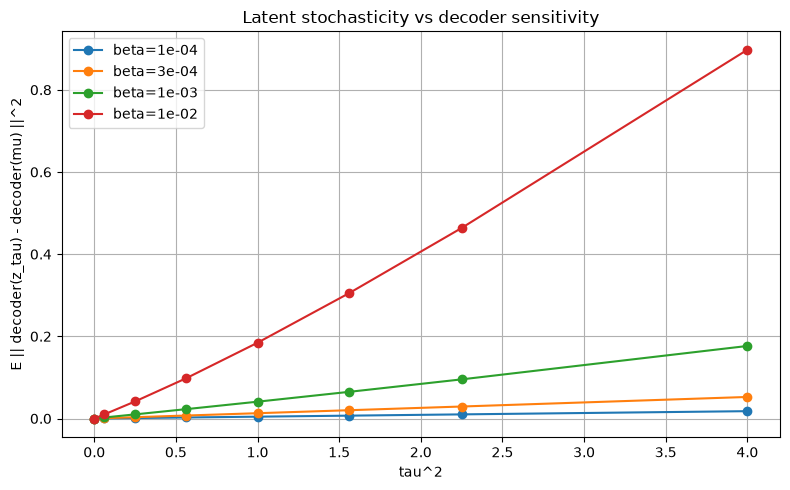

In [10]:
plt.figure(figsize=(8, 5))

for beta in SELECTED:
    df = tau_df[
        tau_df["beta"] == beta
    ]

    plt.plot(
        df["tau2"],
        df["OutputDisp"],
        marker="o",
        label=f"beta={beta:.0e}"
    )

plt.xlabel("tau^2")
plt.ylabel(
    "E || decoder(z_tau) - decoder(mu) ||^2"
)
plt.title(
    "Latent stochasticity vs decoder sensitivity"
)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 11.  Distorsione di ricostruzione al variare di τ

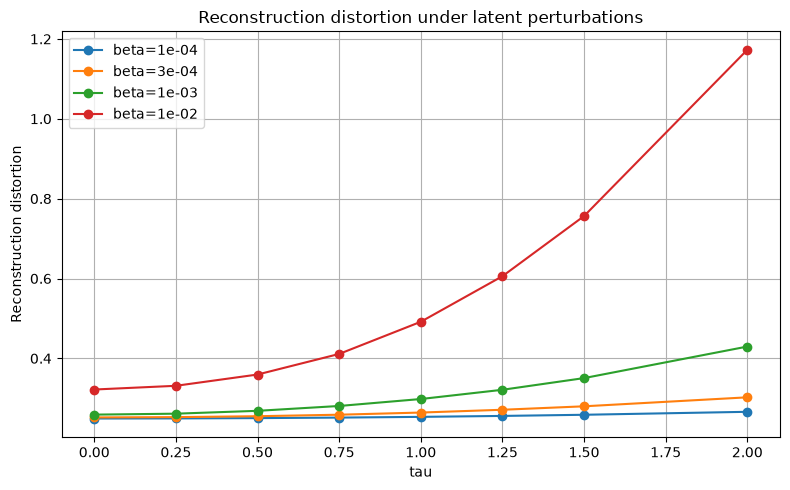

In [11]:
plt.figure(figsize=(8, 5))

for beta in SELECTED:
    df = tau_df[
        tau_df["beta"] == beta
    ]

    plt.plot(
        df["tau"],
        df["ReconD"],
        marker="o",
        label=f"beta={beta:.0e}"
    )

plt.xlabel("tau")
plt.ylabel("Reconstruction distortion")
plt.title(
    "Reconstruction distortion under latent perturbations"
)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 12. Sensibilità quadratica lungo la curva Rate–Distortion

Il coefficiente c ottenuto dal fit quadratico misura quanto rapidamente cambia l’output del decoder quando aumenta la perturbazione latente.

In questa sezione il valore di c viene associato al Rate dei quattro modelli selezionati.

L’obiettivo è verificare se la sensibilità stocastica del decoder cambi in modo sistematico lungo la curva Rate–Distortion.

In [15]:
latent_summary = pd.read_csv(
    RESULTS_DIR / "latent_summary.csv"
)

rate_map = {
    beta: float(
        latent_summary.loc[
            np.isclose(latent_summary["beta"], beta),
            "Rate"
        ].iloc[0]
    )
    for beta in SELECTED
}

fit_df["Rate"] = fit_df["beta"].map(
    rate_map
)

fit_df = fit_df[
    [
        "beta",
        "Rate",
        "Slope_c",
        "Intercept",
        "R2"
    ]
]

fit_df


,beta,Rate,Slope_c,Intercept,R2
0,0.0001,338.115967,0.004465,0.000002,0.999999
1,0.0003,222.941864,0.012894,-0.000001,0.999999
2,0.0010,122.492577,0.040925,-0.000093,0.999952
3,0.0100,33.735149,0.184281,-0.002295,0.998740


## 13. Relazione tra Rate e sensibilità stocastica

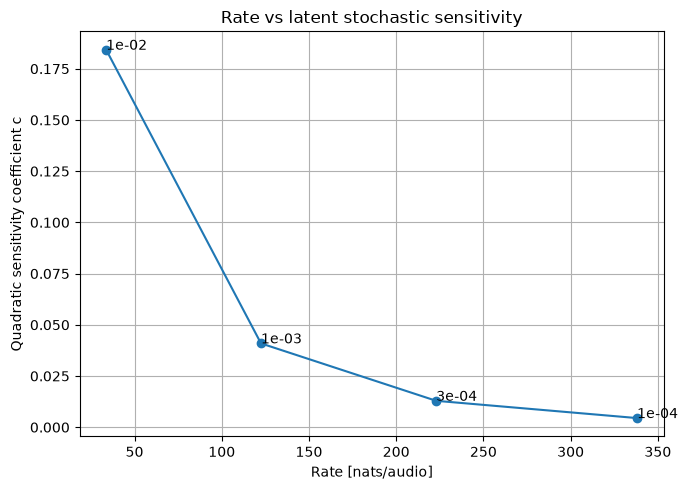

In [20]:
plot_fit = fit_df.sort_values(
    "Rate"
)

plt.figure(figsize=(7, 5))

plt.plot(
    plot_fit["Rate"],
    plot_fit["Slope_c"],
    marker="o"
)

for _, row in plot_fit.iterrows():
    plt.annotate(
        f'{row["beta"]:.0e}',
        (
            row["Rate"],
            row["Slope_c"]
        )
    )

plt.xlabel("Rate [nats/audio]")
plt.ylabel(
    "Quadratic sensitivity coefficient c"
)
plt.title(
    "Rate vs latent stochastic sensitivity"
)
plt.grid(True)
plt.tight_layout()
plt.savefig(
    "report/figures/rate_sensitivity.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "report/figures/rate_sensitivity.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


## 14. Salvataggio dei risultati

In [19]:
tau_df.to_csv(
    RESULTS_DIR / "tau_sweep.csv",
    index=False
)

fit_df.to_csv(
    RESULTS_DIR / "tau_quadratic_fit.csv",
    index=False
)

print("Salvato: results/tau_sweep.csv")
print("Salvato: step12_tau_quadratic_fit.csv")


Salvato: results/tau_sweep.csv
Salvato: step12_tau_quadratic_fit.csv


# Obiettivi dell’analisi

L’analisi mira a verificare tre aspetti principali.

Il primo riguarda la legge esatta nello spazio latente, secondo cui lo spostamento quadratico medio rispetto a μ cresce proporzionalmente a τ².

Il secondo riguarda la sensibilità del decoder: per valori di τ sufficientemente piccoli ci aspettiamo che anche la variazione dell’output segua approssimativamente una legge quadratica.

Infine, confrontiamo il coefficiente di sensibilità c tra modelli con Rate differenti, per verificare se la risposta del decoder alla stocasticità cambi sistematicamente lungo la curva Rate–Distortion.

Questa analisi costituisce il collegamento matematico finale tra struttura latente, sampling e trade-off Rate–Distortion.